#  Text Preprocessing
## Recruitment NLP Lab — Step 3: Cleaning Text Data

This notebook cleans and preprocesses the resume and job description datasets
based on findings from `01_data_exploration.ipynb`.

**Key findings going into preprocessing:**
- Resumes: 2,484 rows, column `Resume_str` contains full text, `Category` is the label
- Job Descriptions: 1,615,940 rows — needs heavy filtering to 4 target domains
- Job `Job Description` column averages only 24 words — will combine with `skills` and `Responsibilities` for richer text
- Resume word counts range from 0 to 5,190 — empty resumes need to be dropped

**Preprocessing Pipeline:**
1. Remove special characters, numbers, punctuation
2. Convert to lowercase
3. Remove stopwords
4. Tokenize
5. Lemmatize

##  1. Install & Import Libraries

In [1]:
!pip install nltk pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# Display settings
pd.set_option('display.max_colwidth', 100)

print(" All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...


 All libraries imported successfully!


[nltk_data]   Package punkt_tab is already up-to-date!


##  2. Load Raw Data

Loading both datasets. Column names confirmed from exploration notebook:
- Resumes text column -> `Resume_str`
- Resumes label column -> `Category`
- Job descriptions text column -> `Job Description`
- Job skills column -> `skills`
- Job responsibilities column -> `Responsibilities`

In [3]:
resumes = pd.read_csv("../data/raw/Resume.csv")
jobs    = pd.read_csv("../data/raw/job_descriptions.csv")

print(f" Resumes loaded          → {resumes.shape[0]:,} rows, {resumes.shape[1]} columns")
print(f" Job Descriptions loaded → {jobs.shape[0]:,} rows, {jobs.shape[1]} columns")

 Resumes loaded          → 2,484 rows, 4 columns
 Job Descriptions loaded → 1,615,940 rows, 23 columns


##  3. Filter to 4 Target Domains

From exploration, the resume category names are in ALL CAPS.
Mapping our 4 domains to their exact category names in the dataset:

| Domain | Resume Category | Job Title Keywords |
|---|---|---|
| Data Science / ML | `INFORMATION-TECHNOLOGY` | Data Analyst, Software Engineer |
| Software Engineering | `ENGINEERING` | Software Engineer, Network Engineer |
| HR / Management | `HR` | HR Coordinator, Executive Assistant |
| Finance / Accounting | `ACCOUNTANT` | Financial Advisor, Procurement Manager |

In [4]:
# Exact category names from the dataset
target_categories = ['HR', 'ACCOUNTANT', 'INFORMATION-TECHNOLOGY', 'ENGINEERING']

filtered_resumes = resumes[resumes['Category'].isin(target_categories)].copy()

print(f" Filtered resumes shape: {filtered_resumes.shape}")
print(f"\nCategory counts:")
print(filtered_resumes['Category'].value_counts())

 Filtered resumes shape: (466, 4)

Category counts:
Category
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
ACCOUNTANT                118
HR                        110
Name: count, dtype: int64


##  4. Enrich Job Description Text

From exploration, `Job Description` column averages only **24 words** — too short
for meaningful NLP. We combine `Job Description` + `skills` + `Responsibilities`
into one rich text column for better model performance.

In [5]:
# Combine Job Description + skills + Responsibilities into one rich text field
jobs['combined_text'] = (
    jobs['Job Description'].fillna('') + ' ' +
    jobs['skills'].fillna('')          + ' ' +
    jobs['Responsibilities'].fillna('')
)

# Verify word count improvement
jobs['combined_word_count'] = jobs['combined_text'].apply(lambda x: len(str(x).split()))

print("=== Combined Text Word Count Stats ===")
print(jobs['combined_word_count'].describe())
print(f"\n Combined text created — average words: {jobs['combined_word_count'].mean():.0f}")

=== Combined Text Word Count Stats ===
count    1.615940e+06
mean     6.400013e+01
std      1.208612e+01
min      3.600000e+01
25%      5.500000e+01
50%      6.200000e+01
75%      7.100000e+01
max      1.050000e+02
Name: combined_word_count, dtype: float64

 Combined text created — average words: 64


##  5. Define Preprocessing Function

A single reusable function that applies all 5 cleaning steps to any text input.

In [6]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    Step 1: Handle null/missing values
    Step 2: Convert to lowercase
    Step 3: Remove special characters, numbers, punctuation
    Step 4: Tokenize
    Step 5: Remove stopwords
    Step 6: Lemmatize
    Returns: cleaned string
    """
    # Step 1: Handle missing
    if pd.isnull(text):
        return ""

    # Step 2: Lowercase
    text = text.lower()

    # Step 3: Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 4: Tokenize
    tokens = word_tokenize(text)

    # Step 5: Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]

    # Step 6: Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

print(" Preprocessing function defined!")

 Preprocessing function defined!


##  6. Test the Function

Testing on a real sample from the resume dataset before applying to the full data.

In [7]:
# Test on a real resume sample from the dataset
sample = filtered_resumes['Resume_str'].iloc[0]

print("ORIGINAL (first 300 chars):")
print(sample[:300])

print("\nPREPROCESSED (first 300 chars):")
print(preprocess_text(sample)[:300])

ORIGINAL (first 300 chars):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

PREPROCESSED (first 300 chars):
hr administratormarketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customerfocused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfactio


##  7. Apply Preprocessing to Resumes

Applying the pipeline to the `Resume_str` column of filtered resumes.
Note: This may take a minute due to the length of resume texts (avg 811 words).

In [8]:
print("Processing resumes...")
filtered_resumes['cleaned_text'] = filtered_resumes['Resume_str'].apply(preprocess_text)

# Drop rows where cleaned text is empty (handles the min=0 word_count outliers found in exploration)
before = len(filtered_resumes)
filtered_resumes = filtered_resumes[filtered_resumes['cleaned_text'].str.strip() != '']
after  = len(filtered_resumes)

print(f" Resumes preprocessed!")
print(f"   Rows before: {before} | Rows after: {after} | Dropped: {before - after}")
print(f"\nSample cleaned resume (first 200 chars):")
print(filtered_resumes['cleaned_text'].iloc[0][:200])

Processing resumes...
 Resumes preprocessed!
   Rows before: 466 | Rows after: 466 | Dropped: 0

Sample cleaned resume (first 200 chars):
hr administratormarketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customerfocused team st


##  8. Apply Preprocessing to Job Descriptions

Applying the pipeline to the enriched `combined_text` column.
Note: The dataset has 1.6M rows — we'll sample a manageable subset
for training to keep processing time reasonable.

##  8. Apply Preprocessing to Job Descriptions

Applying the pipeline to the enriched `combined_text` column.
Note: The dataset has 1.6M rows — we'll sample a manageable subset
for training to keep processing time reasonable.

In [9]:
# Sample 50,000 rows for manageable processing (stratified by Job Title)
jobs_sample = jobs.sample(n=50000, random_state=42).copy()

print(f"Sampled {len(jobs_sample):,} job descriptions for processing...")

jobs_sample['cleaned_text'] = jobs_sample['combined_text'].apply(preprocess_text)

# Drop empty rows
before = len(jobs_sample)
jobs_sample = jobs_sample[jobs_sample['cleaned_text'].str.strip() != '']
after  = len(jobs_sample)

print(f" Job descriptions preprocessed!")
print(f"   Rows before: {before:,} | Rows after: {after:,} | Dropped: {before - after}")
print(f"\nSample cleaned JD (first 200 chars):")
print(jobs_sample['cleaned_text'].iloc[0][:200])

Sampled 50,000 job descriptions for processing...
 Job descriptions preprocessed!
   Rows before: 50,000 | Rows after: 50,000 | Dropped: 0

Sample cleaned JD (first 200 chars):
promote diversity inclusion supply chain manage supplier diversity program assess supplier performance supplier diversity program diversity inclusion initiative supplier assessment certification data 


##  9. Check Missing Values After Preprocessing

In [10]:
print("=== Missing Values After Preprocessing ===")
print(f"\nResumes  — missing cleaned_text: {filtered_resumes['cleaned_text'].isnull().sum()}")
print(f"Jobs     — missing cleaned_text: {jobs_sample['cleaned_text'].isnull().sum()}")
print("\n No missing values remaining!")

=== Missing Values After Preprocessing ===

Resumes  — missing cleaned_text: 0
Jobs     — missing cleaned_text: 0

 No missing values remaining!


##  10. Save Processed Data

In [11]:
# Create output directory
os.makedirs("../data/processed", exist_ok=True)

# Save cleaned datasets — keep only useful columns
filtered_resumes[['ID', 'Category', 'cleaned_text']].to_csv(
    "../data/processed/resumes_cleaned.csv", index=False
)

jobs_sample[['Job Id', 'Job Title', 'Role', 'cleaned_text']].to_csv(
    "../data/processed/jobs_cleaned.csv", index=False
)

print("  Cleaned datasets saved to data/processed/")
print(f"   resumes_cleaned.csv -> {filtered_resumes.shape[0]:,} rows")
print(f"   jobs_cleaned.csv    -> {jobs_sample.shape[0]:,} rows")

  Cleaned datasets saved to data/processed/
   resumes_cleaned.csv -> 466 rows
   jobs_cleaned.csv    -> 50,000 rows


##  11. Visualize Word Count Before vs After Cleaning
Comparing word count distributions to confirm preprocessing worked correctly.

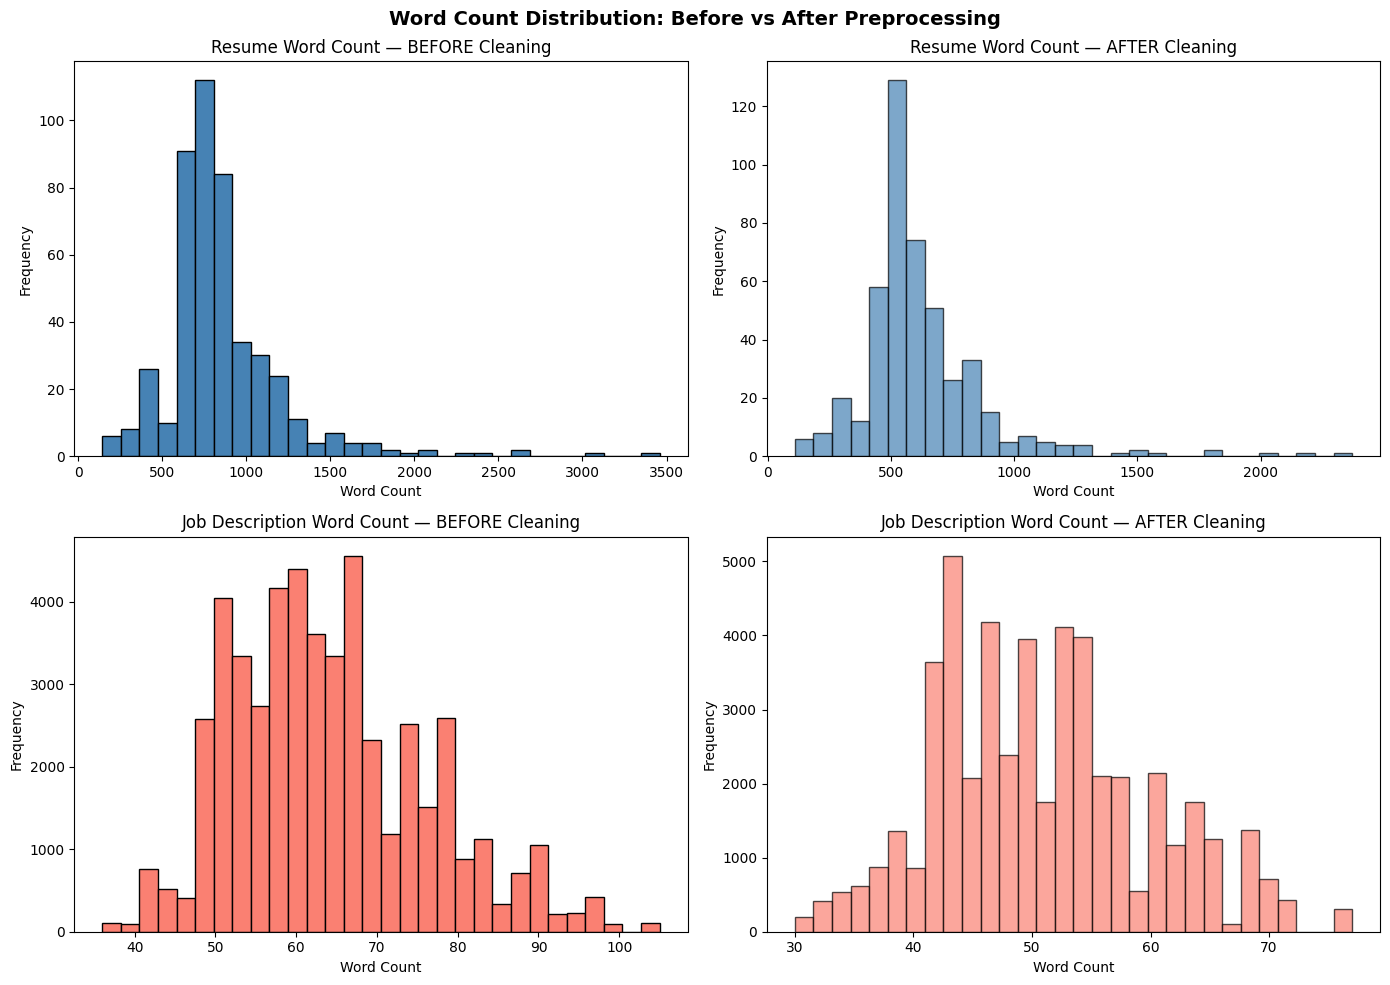

 Plot saved!


In [12]:
filtered_resumes['cleaned_word_count'] = filtered_resumes['cleaned_text'].apply(lambda x: len(x.split()))
jobs_sample['cleaned_word_count']       = jobs_sample['cleaned_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Resume: before
axes[0][0].hist(filtered_resumes['word_count'] if 'word_count' in filtered_resumes.columns
                else filtered_resumes['Resume_str'].apply(lambda x: len(str(x).split())),
                bins=30, color='steelblue', edgecolor='black')
axes[0][0].set_title('Resume Word Count — BEFORE Cleaning', fontsize=12)
axes[0][0].set_xlabel('Word Count')
axes[0][0].set_ylabel('Frequency')

# Resume: after
axes[0][1].hist(filtered_resumes['cleaned_word_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0][1].set_title('Resume Word Count — AFTER Cleaning', fontsize=12)
axes[0][1].set_xlabel('Word Count')
axes[0][1].set_ylabel('Frequency')

# Jobs: before
axes[1][0].hist(jobs_sample['combined_word_count'], bins=30, color='salmon', edgecolor='black')
axes[1][0].set_title('Job Description Word Count — BEFORE Cleaning', fontsize=12)
axes[1][0].set_xlabel('Word Count')
axes[1][0].set_ylabel('Frequency')

# Jobs: after
axes[1][1].hist(jobs_sample['cleaned_word_count'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1][1].set_title('Job Description Word Count — AFTER Cleaning', fontsize=12)
axes[1][1].set_xlabel('Word Count')
axes[1][1].set_ylabel('Frequency')

plt.suptitle('Word Count Distribution: Before vs After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs("../results/plots", exist_ok=True)
plt.savefig("../results/plots/cleaned_word_count_comparison.png")
plt.show()
print(" Plot saved!")

##  12. Summary

| Step | Action | Result |
|---|---|---|
| 1 | Lowercased all text | Uniform case |
| 2 | Removed special chars, numbers, punctuation | Cleaner tokens |
| 3 | Removed NLTK English stopwords | Reduced noise |
| 4 | Tokenized with NLTK word_tokenize | Word-level tokens |
| 5 | Lemmatized with WordNetLemmatizer | Normalized words |
| 6 | Dropped empty resume rows | Removed 0-word outliers |
| 7 | Sampled 50,000 job descriptions | Manageable dataset |
| 8 | Enriched JD text (desc + skills + responsibilities) | Richer text per job |

**Output files saved to `data/processed/`:**
- `resumes_cleaned.csv` -> columns: `ID`, `Category`, `cleaned_text`
- `jobs_cleaned.csv`    -> columns: `Job Id`, `Job Title`, `Role`, `cleaned_text`

**Next Step:** Move to `03_keyword_extraction.ipynb`